# **TP - Un peu de musique**

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio,display
from scipy.io import wavfile

RATE = 44_100
LA = 440
DO = 523.25

## 2.1 Génération d'une sinusoïde

1. Il faut 44100 échantillons pour 1 seconde
2. x(t) = sin(2π(phi)t)
3.

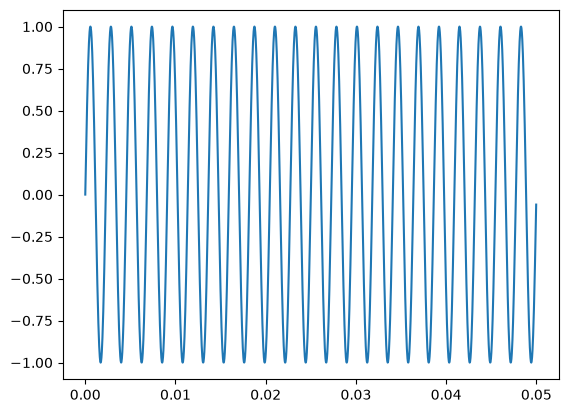

In [113]:
temps = np.linspace(0,1,44100)
position = np.sin(np.multiply(temps,2*np.pi*440))
plt.plot(temps[:int(44100*0.05)],position[:int(44100*0.05)])
plt.show()
display(Audio(position,rate=RATE))

4.

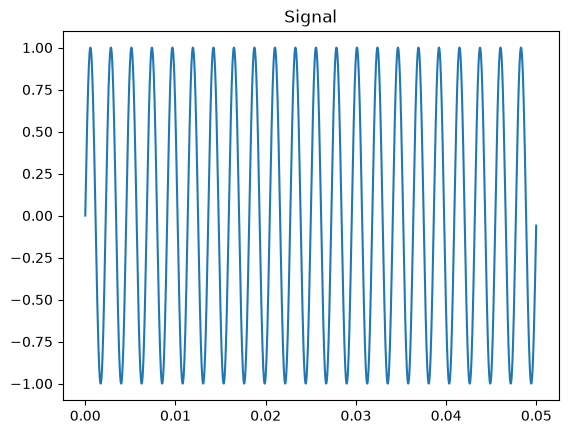

In [114]:
def display_signal(signal,rate=RATE,title="Signal",width=1):
    temps = np.linspace(0,1,rate)
    plt.plot(temps[:int(44100*width)],signal[:int(44100*width)])
    plt.title(title)
    plt.show()
    display(Audio(signal,rate=rate))

display_signal(position,width=0.05)

## Généralisation : la fonction sine()

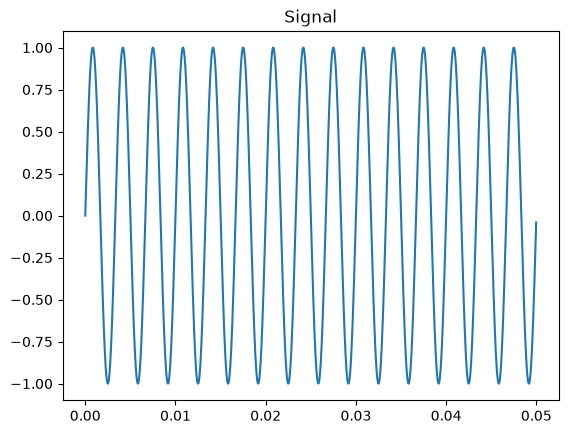

In [115]:
def sine(freq,duration=1,amplitude=1.):
    temps = np.linspace(0,duration,RATE*duration)
    signal = amplitude * np.sin(np.multiply(temps,2*np.pi*freq))
    return signal

display_signal(sine(300),width=0.05)

## 2.3 Pour aller plus loin : glissando (Effet "note qui monte")

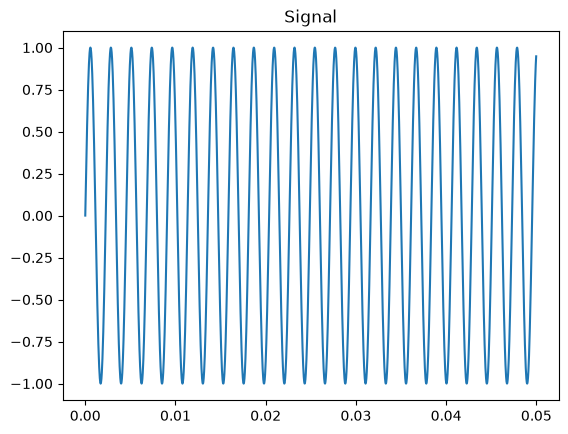

In [116]:
def sine_linear(freq1,freq2,duration=1):
    temps = np.linspace(0,duration,RATE*duration)
    frequence = np.linspace(freq1,freq2,RATE*duration)
    signal = np.sin(2*np.pi*np.multiply(temps,frequence))
    return signal

display_signal(sine_linear(440,523.25),width=0.05)

Meilleure version : (à refaire)

In [117]:
def sine_linear(freq1,freq2,duration=1):
    temps = np.linspace(0,duration,RATE*duration)
    frequence = np.linspace(freq1,freq2,RATE*duration)
    signal = np.sin(2*np.pi*np.sum(temps,frequence))
    return signal

display_signal(sine_linear(440,523.25),width=0.05)

TypeError: only integer scalar arrays can be converted to a scalar index

## 3.1 Création d'un crescendo

1. On peut refaire un np.linspace pour l'amplitude.
2. et 3.

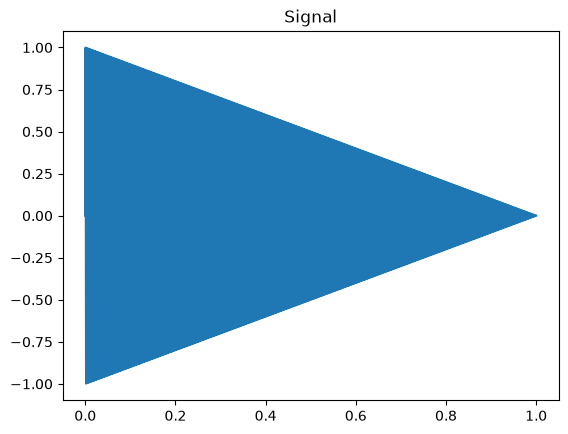

In [ ]:
def crescendo_sine(freq,duration=1,increase=True):
    temps = np.linspace(0,duration,RATE*duration)
    if increase:
        amp = np.linspace(0,1,RATE*duration)
    else:
        amp = np.linspace(1,0,RATE*duration)
    signal = np.multiply(amp,np.sin(np.multiply(temps,2*np.pi*freq)))
    return signal

display_signal(crescendo_sine(440,increase=False))

## 4. Concaténation de sons

In [ ]:
temps1 = np.linspace(0,1,RATE)
la = np.sin(np.multiply(temps1,2*np.pi*440))
do = np.sin(np.multiply(temps1,2*np.pi*523.25))
succession = np.concatenate((la,do))
display(Audio(succession,rate=RATE))

## 5.3 Mise à l'échelle

In [ ]:
def float_to_int16(as_float):
    return (as_float * 32767).astype(np.int16)

[    0     0     1 ... 32765 32766 32767]


## 6.2 Calcul des rapports

In [ ]:
ratios = np.array([(2**(1/12))**i for i in range(13)])
notes = {"do":0,"do#":1,"ré":2,"ré#":3,"mi":4,"fa":5,"fa#":6,"sol":7,"sol#":8,"la":9,"la#":10,"si":11}
def freq_from_name(name):
    i = notes[name]
    return 440*2**((i-9)/12)

print(freq_from_name("la"))

440.0


## 7. Les accords : Superposition de sons

Il faut additionner les tableaux.

## 8. Sauvegarde et chargement de fichiers .wav

In [127]:
wavfile.write("sample.wav",RATE,succession)
rate,restored = wavfile.read("sample.wav")
display(Audio(restored,rate=rate))

## 9. Analyse d'un son réel

44100
405891
9.203877551020408


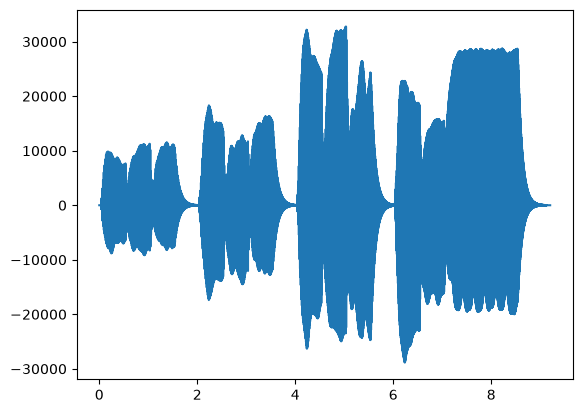

In [147]:
samplerate,data = wavfile.read("media/sounds-cello.wav")
display(Audio(data,rate=rate))
print(samplerate)
n = len(data) #nb total d'échantillons
print(n)
duree = len(data)/rate #durée du morceau
print(duree)
plt.plot(np.linspace(0,duree,n),data)
plt.show()


## 10. Ajout d'un effet d'écho

Pour la question 11.2, utiliser astype (passer en int32 pour le calcul et revenir en int16)